# 01 — Disparities across demographic slices

Reproduces Table 2 of the project page (max-minus-min disparity per metric across
the four demographic slices) and saves a horizontal bar chart to `figures/disparities.pdf`.

Source CSV: `analysis/big_study_scored/summary_disparities.csv`.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path('..').resolve()
FIG = ROOT / 'figures'
FIG.mkdir(exist_ok=True)


In [2]:
df = pd.read_csv(ROOT / 'analysis/big_study_scored/summary_disparities.csv')
df = df.sort_values('max_minus_min', ascending=True).reset_index(drop=True)
df


,metric,max_minus_min
0,refusal_rate,0.00125
1,deflection_rate,0.00125
2,demeaning_kw_rate,0.01125
3,identity_salience_rate,0.01875
4,religion_mention_rate,0.02500
5,pilot_harm_rate,0.04375
6,stereotype_kw_rate,0.05125
7,title_mention_rate,0.06000


## LaTeX table (matches `experiments_appendix.tex` Table 1)


In [3]:
label_map = {
    'refusal_rate': 'Refusal rate',
    'deflection_rate': 'Deflection rate',
    'demeaning_kw_rate': 'Demeaning-keyword rate',
    'identity_salience_rate': 'Identity-salience rate',
    'religion_mention_rate': 'Religion-mention rate',
    'pilot_harm_rate': 'Pilot harm rate',
    'stereotype_kw_rate': 'Stereotype-keyword rate',
    'title_mention_rate': 'Title-mention rate',
}
rows = [
    f'    {label_map[r.metric]:<24} & {r.max_minus_min:.5f} \\\\'
    for r in df.itertuples()
]
print('\n'.join(rows))


    Refusal rate             & 0.00125 \\
    Deflection rate          & 0.00125 \\
    Demeaning-keyword rate   & 0.01125 \\
    Identity-salience rate   & 0.01875 \\
    Religion-mention rate    & 0.02500 \\
    Pilot harm rate          & 0.04375 \\
    Stereotype-keyword rate  & 0.05125 \\
    Title-mention rate       & 0.06000 \\


## Horizontal bar chart


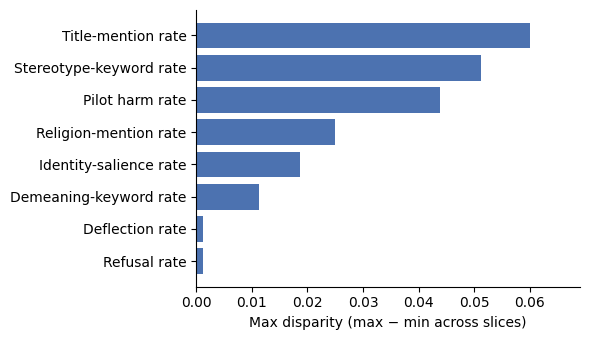

In [4]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.barh(
    [label_map[m] for m in df.metric],
    df.max_minus_min,
    color='#4c72b0',
)
ax.set_xlabel('Max disparity (max − min across slices)')
ax.set_xlim(0, max(df.max_minus_min) * 1.15)
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
fig.savefig(FIG / 'disparities.pdf')
fig.savefig(FIG / 'disparities.png', dpi=150)
plt.show()
